In [1]:
import torch
from torch import nn
import torch.nn.functional  as F
import torchvision
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, Compose, transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

100%|██████████| 170M/170M [00:04<00:00, 34.8MB/s]


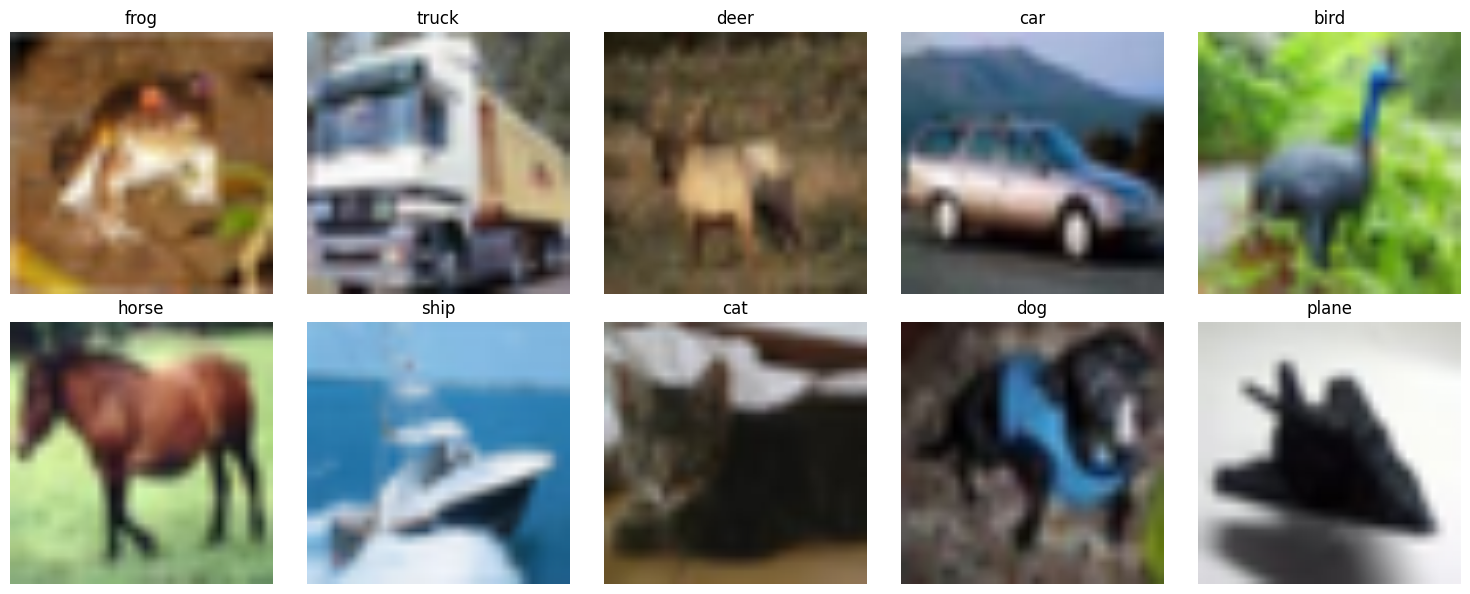

Number of training samples: 50000
Number of test samples: 10000
Number of classes: 10
Image shape: torch.Size([3, 224, 224])


In [2]:
# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize for consistency
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])



# CIFAR-10 classes
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')


trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)




# Function to show one image from each class
def show_one_per_class(dataset, classes):
    # Create a dictionary to track which classes we've found
    found_classes = {}

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.ravel()

    for i, (image, label) in enumerate(dataset):
        class_name = classes[label]

        # If we haven't found this class yet
        if class_name not in found_classes:
            found_classes[class_name] = image
            if len(found_classes) == len(classes):
                break

    # Plot one image from each class
    for idx, (class_name, image) in enumerate(found_classes.items()):
        # Convert tensor to numpy and denormalize
        img = image.numpy().transpose((1, 2, 0))
        img = img * 0.5 + 0.5  # Denormalize
        img = np.clip(img, 0, 1)

        axes[idx].imshow(img)
        axes[idx].set_title(class_name)
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

# Show one image from each class
show_one_per_class(trainset, classes)

# Dataset information
print(f"Number of training samples: {len(trainset)}")
print(f"Number of test samples: {len(testset)}")
print(f"Number of classes: {len(classes)}")
print(f"Image shape: {trainset[0][0].shape}")

In [3]:
class VGG(nn.Module):
    def __init__(self, in_channels=3, num_classes=10):
        super(VGG, self).__init__()
        
        # Reduced channel sizes for memory efficiency
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),
            
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),
        )
        
        # Adaptive pooling to handle different input sizes
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        
        self.classifier = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [4]:
for image, label in enumerate( train_loader):
  break
b1 = label[0]

In [5]:
print(b1.shape)
c1 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding=1)
x = c1(b1)
print(x.shape)

torch.Size([64, 3, 224, 224])
torch.Size([64, 8, 224, 224])


In [6]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



Using device: cuda


In [7]:
from torch.optim.lr_scheduler import StepLR

# Initialize model, criterion, optimizer
model = VGG(in_channels=3, num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)


Epoch [1/20] Train Loss: 1.9092 Test Loss: 1.6001 Test Acc: 42.65%
Epoch [2/20] Train Loss: 1.6792 Test Loss: 1.4543 Test Acc: 46.13%
Epoch [3/20] Train Loss: 1.5439 Test Loss: 1.2772 Test Acc: 54.42%
Epoch [4/20] Train Loss: 1.4135 Test Loss: 1.1699 Test Acc: 58.83%
Epoch [5/20] Train Loss: 1.3077 Test Loss: 1.0801 Test Acc: 62.40%
Epoch [6/20] Train Loss: 1.1541 Test Loss: 0.9694 Test Acc: 66.53%
Epoch [7/20] Train Loss: 1.1028 Test Loss: 0.9451 Test Acc: 67.77%
Epoch [8/20] Train Loss: 1.0807 Test Loss: 0.9177 Test Acc: 68.29%
Epoch [9/20] Train Loss: 1.0514 Test Loss: 0.8965 Test Acc: 69.45%
Epoch [10/20] Train Loss: 1.0287 Test Loss: 0.8798 Test Acc: 69.66%
Epoch [11/20] Train Loss: 1.0019 Test Loss: 0.8645 Test Acc: 70.00%
Epoch [12/20] Train Loss: 0.9996 Test Loss: 0.8606 Test Acc: 70.25%
Epoch [13/20] Train Loss: 0.9963 Test Loss: 0.8553 Test Acc: 70.39%
Epoch [14/20] Train Loss: 0.9906 Test Loss: 0.8535 Test Acc: 70.50%
Epoch [15/20] Train Loss: 0.9850 Test Loss: 0.8536 Test A

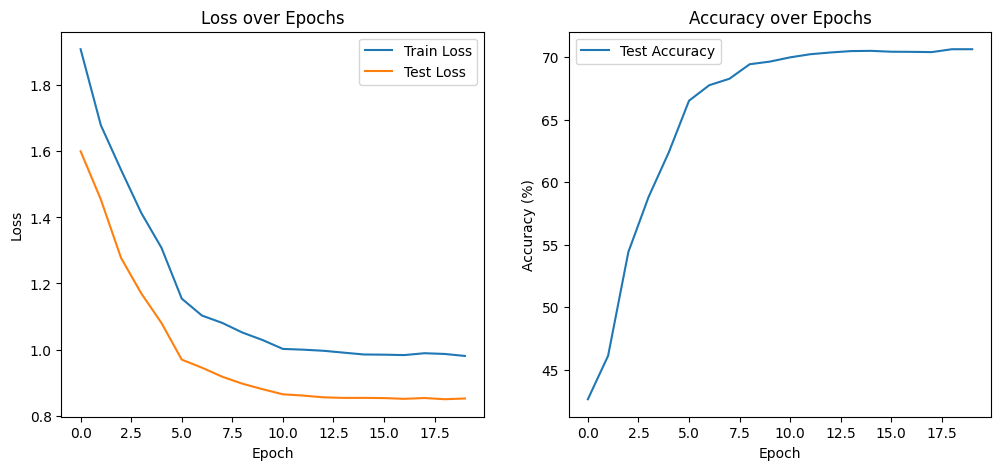

In [8]:
num_epochs = 20
train_losses, test_losses, test_accuracies = [], [], []
batch = 0
for epoch in range(num_epochs):
    # train
    model.train()
    
    running_loss = 0.0
    for images, labels in train_loader:
        batch+=1
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        # if batch %100 ==0:
        #     print('batch ', batch, 'loss', loss )
        
        optimizer.step()
        optimizer.zero_grad()
        running_loss += loss.item()


    train_losses.append(running_loss / len(train_loader))

    # eval
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    test_losses.append(test_loss / len(testloader))
    test_accuracies.append(100 * correct / total)


    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_losses[-1]:.4f} "
          f"Test Loss: {test_losses[-1]:.4f} "
          f"Test Acc: {test_accuracies[-1]:.2f}%")

# -------------------
# 6. Plot
# -------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy over Epochs")
plt.legend()

plt.show()


In [9]:
for image,labe in train_loader:
  break

In [10]:
image.shape

torch.Size([64, 3, 224, 224])